# Notebook 6 — Experiment 4: V4 Final — Hard + Easy Negatives, No Normalization  ← SUBMITTED MODEL

## What this experiment changes
Final pipeline. Same clean verifier fall labeling as Exp 3, but ADL strategy is extended with **easy negatives** in addition to hard negatives. Easy negatives (acc < EASY_THRESH) ensure the model sees realistic low-motion deployment windows. No normalization — raw physical units throughout.

| Setting | This experiment |
|---|---|
| Fall labeling | ONE 500ms window centred on impact peak (clean verifier) |
| ADL strategy | Hard negatives (acc ≥ HARD_THRESH, top-3) + Easy negatives (acc < EASY_THRESH, random 5) |
| Normalization | None (raw physical units) |

**Expected result:** Best overall results. Easy negatives add realistic deployment-time context without diluting the hard negative signal.

**Prerequisites:** Run Notebook 1 (split) and Notebook 2 (thresholds) first.

---
## Requirements
```
scikit-learn>=1.2.0  numpy>=1.23.0  tensorflow>=2.12.0  matplotlib>=3.6.0  seaborn>=0.12.0
```


## Cell 1 — Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Cell 2 — Install dependencies

In [2]:
!pip install scikit-learn tensorflow -q
print('Done')

Done


## Cell 3 — Configuration

In [3]:
import os
import json
import random
import numpy as np
from sklearn.model_selection import train_test_split
from collections import defaultdict
import glob
import pandas as pd

# ── Paths ──────────────────────────────────────────────────────────────
DATASET_DIR   = '/content/drive/MyDrive/M4/Data_Collected'
SPLIT_PATH    = '/content/drive/MyDrive/M4/01.npz'
ANALYSIS_JSON = '/content/drive/MyDrive/M4/02_analysis.json'

# ── Windowing parameters ───────────────────────────────────────────────
WIN_SAMPLES = 50    # 500 ms at 100 Hz
STRIDE      = 20    # 200 ms stride (60% overlap)

# ── Split parameters ───────────────────────────────────────────────────
RANDOM_SEED = 42
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

# ── Volunteer lists ────────────────────────────────────────────────────
ALL_VOLUNTEERS = [
    'V1_Sama', 'V2_Shams', 'V3_Mary', 'V4_Yasamin',
    'V5_Betty', 'V6_Jannah', 'V7_Warda', 'V8_Ismat',
    'V10_Isham'
]

# ── Activity codes — auto-detected from filenames ──────────────────────
_all_csvs  = glob.glob(os.path.join(DATASET_DIR, '**', '*.csv'), recursive=True)
FALL_CODES = sorted(set(
    os.path.basename(f)[:3] for f in _all_csvs
    if os.path.basename(f)[0].upper() == 'F'
))
ADL_CODES  = sorted(set(
    os.path.basename(f)[:3] for f in _all_csvs
    if os.path.basename(f)[0].upper() == 'D'
))

# ── Derived constants from Notebook 2 analysis ────────────────────────
HARD_THRESH   = 1.493   # updated from Notebook 2 trial-wise split
EASY_THRESH   = 1.137   # updated from Notebook 2 trial-wise split
STILL_MEAN     = 1.20    # just above max observed stillness (1.18g)
MIN_STILL      = 50      # 500ms — volunteers get up quickly
TRIM_SAMPLES   = 100
MAX_HARD       = 3
MAX_EASY       = 5
FALL_PRE       = 25
FALL_POST      = 25
# POST_STILL_MAX — REMOVED (volunteers naturally get up after falling)

# ── EXCLUDE ───────────────────────────────────────────────────────────
EXCLUDE = {
    'V1_Sama/D11_01.csv', 'V1_Sama/F04_05.csv',
    'V1_Sama/D07_03.csv', 'V1_Sama/D17_01.csv',
    'V1_Sama/D02_01.csv', 'V1_Sama/F01_01.csv',
    'V10_Isham/F01_01.csv', 'V10_Isham/F01_02.csv', 'V10_Isham/F01_03.csv',
    'V10_Isham/F02_02.csv', 'V10_Isham/F03_02.csv', 'V10_Isham/F03_03.csv',
    'V10_Isham/F03_04.csv', 'V10_Isham/F04_01.csv', 'V10_Isham/F06_01.csv',
    'V10_Isham/F09_01.csv',
    'V2_Shams/F02_01.csv', 'V2_Shams/F03_02.csv',
    'V2_Shams/F07_01.csv', 'V2_Shams/F14_01.csv',
    'V3_Mary/F02_01.csv',  'V3_Mary/F02_02.csv',
    'V3_Mary/F03_01.csv',  'V3_Mary/F03_02.csv',
    'V4_Yasamin/F01_01.csv', 'V4_Yasamin/F03_01.csv',
    'V5_Betty/F03_01.csv',   'V5_Betty/F11_01.csv',
    'V6_Jannah/F05_01.csv',  'V6_Jannah/F06_01.csv',
    'V6_Jannah/F07_01.csv',  'V6_Jannah/F09_01.csv',
    'V6_Jannah/F12_01.csv',
    'V7_Warda/F01_01.csv',  'V7_Warda/F01_03.csv',
    'V7_Warda/F04_01.csv',  'V7_Warda/F05_01.csv',
    'V7_Warda/F06_01.csv',  'V7_Warda/F07_01.csv',
    'V7_Warda/F09_01.csv',  'V7_Warda/F12_01.csv',
}

print('Configuration set')
print(f'  Volunteers : {len(ALL_VOLUNTEERS)}')
print(f'  Fall codes : {len(FALL_CODES)} → {FALL_CODES}')
print(f'  ADL codes  : {len(ADL_CODES)}  → {ADL_CODES}')
print(f'  Excluded   : {len(EXCLUDE)} files')
print(f'  HARD_THRESH: {HARD_THRESH}g  EASY_THRESH: {EASY_THRESH}g')
print(f'  STILL_MEAN : {STILL_MEAN}g   MIN_STILL  : {MIN_STILL} samples')


Configuration set
  Volunteers : 9
  Fall codes : 16 → ['F01', 'F02', 'F03', 'F04', 'F05', 'F06', 'F07', 'F08', 'F09', 'F10', 'F11', 'F12', 'F13', 'F14', 'F15', 'fal']
  ADL codes  : 19  → ['D01', 'D02', 'D03', 'D04', 'D05', 'D06', 'D07', 'D08', 'D09', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'D16', 'D17', 'D18', 'D19']
  Excluded   : 41 files
  HARD_THRESH: 1.493g  EASY_THRESH: 1.137g
  STILL_MEAN : 1.2g   MIN_STILL  : 50 samples


## Cell 4 — Helper functions
Same sensor loading and SMV helpers as Notebooks 1 and 2.

In [4]:
def load_trial(filepath):
    """
    Read one collected CSV file and return physical-unit sensor data.
    Files are already cleaned with header: t_ms,ax_g,ay_g,az_g,gx_dps,gy_dps,gz_dps
    Data is already in physical units (g and dps) — no scaling needed.
    First and last TRIM_SAMPLES rows removed to avoid recording artifacts.

    Returns:
      accel [N, 3] in g    (ax_g, ay_g, az_g)
      gyro  [N, 3] in dps  (gx_dps, gy_dps, gz_dps)
      Returns (None, None) if file has fewer than WIN_SAMPLES rows.
    """
    cols = ['t_ms','ax_g','ay_g','az_g','gx_dps','gy_dps','gz_dps']

    header_line = None
    with open(filepath, 'rb') as f:
        for i, line in enumerate(f):
            if line.strip().startswith(b't_ms'):
                header_line = i; break
    if header_line is None:
        return None, None

    try:
        df = pd.read_csv(filepath, skiprows=header_line, on_bad_lines='skip')
        for c in cols:
            df[c] = pd.to_numeric(df[c], errors='coerce')
        df = df.dropna(subset=cols)[['ax_g','ay_g','az_g','gx_dps','gy_dps','gz_dps']]
    except Exception as e:
        print(f'  Parse error {filepath}: {e}')
        return None, None

    df = df.iloc[TRIM_SAMPLES:-TRIM_SAMPLES]
    if len(df) < WIN_SAMPLES:
        return None, None

    accel = df[['ax_g','ay_g','az_g']].values.astype(np.float32)
    gyro  = df[['gx_dps','gy_dps','gz_dps']].values.astype(np.float32)
    return accel, gyro


def downsample(signal):
    """
    NOT needed — pass-through only.
    Arduino LSM9DS1 natively at 100 Hz.
    SisFall needed [::2] decimation from 200 Hz.
    """
    return signal.astype(np.float32)


def smv(a):
    """Signal Magnitude Vector: sqrt(x² + y² + z²) per sample."""
    return np.sqrt(np.sum(a ** 2, axis=1))


print('Helper functions defined')

Helper functions defined


## Cell 5 — Load split and thresholds

Loads the exact same trial split produced by Notebook 1.
Loads the exact same thresholds derived by Notebook 2.
This guarantees all four experiments use identical splits and identical thresholds.


In [5]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
print('TF version:', tf.__version__)
print()

# ── Load the trial split from Notebook 1 ─────────────────────────────
data = np.load(SPLIT_PATH, allow_pickle=True)

def unpack_trials(data, prefix):
    """Reconstruct trial dicts from packed NPZ arrays."""
    accels     = data[f'{prefix}_accels']
    gyros      = data[f'{prefix}_gyros']
    volunteers = data[f'{prefix}_volunteers']
    codes      = data[f'{prefix}_codes']
    trials = []
    for a, g, v, c in zip(accels, gyros, volunteers, codes):
        trials.append({
            'volunteer':     str(v),
            'activity_code': str(c),
            'is_fall':       str(c) in FALL_CODES,
            'accel_ds':      np.array(a, dtype=np.float32),
            'gyro_ds':       np.array(g, dtype=np.float32),
            'a_smv':         smv(np.array(a, dtype=np.float32)),
            'g_smv':         smv(np.array(g, dtype=np.float32)),
        })
    return trials

fall_train = unpack_trials(data, 'fall_train')
fall_val   = unpack_trials(data, 'fall_val')
fall_test  = unpack_trials(data, 'fall_test')
adl_train  = unpack_trials(data, 'adl_train')
adl_val    = unpack_trials(data, 'adl_val')
adl_test   = unpack_trials(data, 'adl_test')


print()

# ── Load thresholds from Notebook 2 — or use hardcoded derived values ─
# NOTE: If ANALYSIS_JSON doesn't exist yet, hardcoded values from
#       Notebook 2 analysis are used directly.
if os.path.exists(ANALYSIS_JSON):
    with open(ANALYSIS_JSON) as f:
        cfg = json.load(f)
    STILL_MEAN  = cfg['STILL_MEAN']
    MIN_STILL   = cfg['MIN_STILL']
    FALL_PRE    = cfg['FALL_PRE']
    FALL_POST   = cfg['FALL_POST']
    HARD_THRESH = cfg['HARD_THRESH']
    EASY_THRESH = cfg['EASY_THRESH']
    MAX_HARD    = cfg['MAX_HARD']
    MAX_EASY    = cfg['MAX_EASY']
    rng = np.random.RandomState(cfg.get('RANDOM_SEED', 42))
    print('Loaded thresholds from ANALYSIS_JSON')
else:
    # Hardcoded from Notebook 2 analysis on collected data
    STILL_MEAN  = 1.20
    MIN_STILL   = 50
    FALL_PRE    = 25
    FALL_POST   = 25
    HARD_THRESH = 1.493
    EASY_THRESH = 1.137
    MAX_HARD    = 3
    MAX_EASY    = 5
    rng = np.random.RandomState(42)
    print('⚠ ANALYSIS_JSON not found — using hardcoded derived values')

# POST_STILL_MAX and PER_TYPE_THRESHOLDS removed —
# volunteers naturally get up after falling

print(f'\nFall  — Train: {len(fall_train)}  Val: {len(fall_val)}  Test: {len(fall_test)}')
print(f'ADL   — Train: {len(adl_train)}   Val: {len(adl_val)}   Test: {len(adl_test)}')
print()
print(f'STILL_MEAN  = {STILL_MEAN}   MIN_STILL  = {MIN_STILL}')
print(f'HARD_THRESH = {HARD_THRESH}  EASY_THRESH = {EASY_THRESH}')
print(f'FALL_PRE    = {FALL_PRE}     FALL_POST   = {FALL_POST}')

TF version: 2.20.0


Loaded thresholds from ANALYSIS_JSON

Fall  — Train: 77  Val: 17  Test: 17
ADL   — Train: 125   Val: 27   Test: 27

STILL_MEAN  = 1.2   MIN_STILL  = 50
HARD_THRESH = 1.493  EASY_THRESH = 1.137
FALL_PRE    = 25     FALL_POST   = 25


## Cell 6 — Impact detector and window extraction helpers

### `detect_impact(a_smv, g_smv, acc_thresh, gyr_thresh, high_acc)`
Locates the fall impact peak in a trial signal using four conditions:
1. Acc peak ≥ acc_thresh
2. Gyro peak ≥ gyr_thresh within ±1s of impact (OR acc ≥ high_acc override)
3. Sustained post-impact stillness: mean < STILL_MEAN for ≥ MIN_STILL samples
4. No activity resumption: no acc > POST_STILL_MAX after the stillness

### `get_fall_window(trial)`
Returns the single 500ms window centred on the detected impact peak.
Used by Experiments 3 and 4.

### `build_baseline_cnn()`
Same architecture for all four experiments so results are directly comparable.


In [6]:
def detect_impact(a_smv, g_smv):
    n  = len(a_smv); pk = int(np.argmax(a_smv)); ap = float(a_smv[pk])
    gs = max(0, pk-100); ge = min(n, pk+100);    gp = float(g_smv[gs:ge].max())
    if not (ap >= 1.4 and (gp >= 90.0 or ap >= 4.0)): return None
    ss = -1
    for i in range(pk+1, n-MIN_STILL):
        if a_smv[i:i+MIN_STILL].mean() < STILL_MEAN: ss = i; break
    if ss == -1: return None
    # Condition 4 REMOVED
    return pk

def get_fall_window(trial):
    pk = detect_impact(trial['a_smv'], trial['g_smv'])
    if pk is None: return None
    raw6 = np.concatenate([trial['accel_ds'], trial['gyro_ds']], axis=1)
    s, e = pk-FALL_PRE, pk+FALL_POST
    if s < 0 or e > len(raw6): return None
    return raw6[s:e].astype(np.float32)


def build_baseline_cnn(input_shape=(50, 6)):
    """
    Same CNN architecture used in all 4 experiments.
    Keeps comparisons fair — only the dataset construction changes.

    Input  : [50, 6] raw IMU window (accel XYZ + gyro XYZ)
    Output : scalar fall probability in [0, 1]
    Params : 14,417 (~56 KB float32)
    """
    inp = keras.Input(shape=input_shape, name='imu_window')
    x = layers.Conv1D(16, kernel_size=3, activation='relu', padding='same')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Conv1D(32, kernel_size=3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(1, activation='sigmoid', name='fall_prob')(x)
    return keras.Model(inputs=inp, outputs=out, name='baseline_cnn')


print('Impact detector and helper functions defined')


Impact detector and helper functions defined


## Cell 7 — Build dataset: Experiment 4  ← FINAL MODEL

**Fall labeling:** Same clean verifier as Experiment 3 — one centred 500ms impact window per trial.

**ADL labeling:** Two complementary strategies:
- **Hard negatives** (acc ≥ HARD_THRESH): top-3 most fall-like ADL windows per trial.
  Forces the model to learn fine-grained ADL-vs-fall discrimination.
- **Easy negatives** (acc < EASY_THRESH): 5 randomly sampled low-motion windows per trial.
  In real deployment, ~95% of windows are low-motion (normal walking, sitting).
  Without easy negatives, the model was never trained on these and may behave erratically.

**No normalization:** Raw physical units (g and dps) used throughout.
Normalization experiment showed negligible performance difference (sensitivity 0.9925 vs 0.9886)
at the cost of storing 12 values (6 means + 6 stds) and performing 12 divisions per inference.
For TinyML deployment this overhead is avoided.


In [7]:
def detect_impact(a_smv, g_smv):
    """
    Locate fall impact peak.
    Condition 4 (post-stillness activity) REMOVED —
    volunteers naturally get up after falling unlike SisFall subjects.
    """
    n  = len(a_smv); pk = int(np.argmax(a_smv)); ap = float(a_smv[pk])
    gs = max(0, pk-100); ge = min(n, pk+100);    gp = float(g_smv[gs:ge].max())
    if not (ap >= 1.4 and (gp >= 90.0 or ap >= 4.0)): return None
    ss = -1
    for i in range(pk+1, n-MIN_STILL):
        if a_smv[i:i+MIN_STILL].mean() < STILL_MEAN: ss = i; break
    if ss == -1: return None
    # Condition 4 REMOVED
    return pk

def get_fall_window(trial):
    """One centred impact window per fall trial."""
    pk = detect_impact(trial['a_smv'], trial['g_smv'])
    if pk is None: return None
    raw6 = np.concatenate([trial['accel_ds'], trial['gyro_ds']], axis=1)
    s, e = pk-FALL_PRE, pk+FALL_POST
    if s < 0 or e > len(raw6): return None
    return raw6[s:e].astype(np.float32)

def get_adl_windows_v4(trial):
    """
    Select ADL windows using two complementary strategies:
    Hard negatives (acc >= HARD_THRESH):
      The top-MAX_HARD windows by peak acceleration — the most fall-like ADL moments.
      Forces fine-grained discrimination near the decision boundary.
    Easy negatives (acc < EASY_THRESH):
      MAX_EASY randomly sampled low-motion windows — normal walking, sitting, etc.
      Ensures the model sees realistic deployment-time windows (95%+ of real usage).
    Both thresholds derived from train+val ADL distribution (Notebook 2).
    """
    raw6 = np.concatenate([trial['accel_ds'], trial['gyro_ds']], axis=1)
    a    = trial['a_smv']
    hard = []; easy = []
    for w in range(0, len(raw6) - WIN_SAMPLES + 1, STRIDE):
        pk  = float(a[w:w + WIN_SAMPLES].max())
        win = raw6[w:w + WIN_SAMPLES]
        if   pk >= HARD_THRESH: hard.append((pk, win))
        elif pk <  EASY_THRESH: easy.append(win)
    hard.sort(key=lambda x: -x[0])
    hw = [win for _, win in hard[:MAX_HARD]]
    if len(easy) > MAX_EASY:
        idx  = rng.choice(len(easy), MAX_EASY, replace=False)
        easy = [easy[i] for i in idx]
    return hw + easy

def build_windows_exp4(fall_list, adl_list, split_name):
    """
    Experiment 4 (final): clean verifier + hard and easy negatives, no normalization.
    Fall windows : ONE centred impact window per trial
    ADL windows  : hard negatives (top-3) + easy negatives (random 5)
    """
    windows = []; labels = []
    detected = 0; skipped = 0; skipped_names = []

    # ── Fall trials: one centred impact window ─────────────────────────
    for trial in fall_list:
        win = get_fall_window(trial)
        if win is not None:
            windows.append(win); labels.append(1)
            detected += 1
        else:
            skipped += 1
            skipped_names.append(f"{trial['volunteer']}/{trial['activity_code']}")

    # ── ADL trials: hard + easy negatives ─────────────────────────────
    for trial in adl_list:
        for win in get_adl_windows_v4(trial):
            windows.append(win); labels.append(0)

    X = np.array(windows, dtype=np.float32)
    y = np.array(labels,  dtype=np.int32)
    print(f'  {split_name:6s}: {len(y):>6,} windows | '
          f'Falls={y.sum():,} ({100*y.mean():.1f}%) | ADLs={(y==0).sum():,} | '
          f'Det={detected}/{detected+skipped} ({100*detected/max(1,detected+skipped):.1f}%)')
    if skipped_names:
        print(f'    ⚠ Skipped: {skipped_names}')
    return X, y

EXP_NAME = 'exp4_collected_final'
print(f'Building dataset for {EXP_NAME}...')
print()

X_train, y_train = build_windows_exp4(fall_train, adl_train, 'Train')
X_val,   y_val   = build_windows_exp4(fall_val,   adl_val,   'Val')
X_test,  y_test  = build_windows_exp4(fall_test,  adl_test,  'Test')

imb          = (y_train == 0).sum() / y_train.sum()
CLASS_WEIGHT = {0: 1.0, 1: round(float(imb), 1)}
print(f'\nClass imbalance (train): {imb:.1f}:1')
print(f'Class weight           : {CLASS_WEIGHT}')

Building dataset for exp4_collected_final...

  Train :    862 windows | Falls=76 (8.8%) | ADLs=786 | Det=76/77 (98.7%)
    ⚠ Skipped: ['V1_Sama/F02']
  Val   :    187 windows | Falls=17 (9.1%) | ADLs=170 | Det=17/17 (100.0%)
  Test  :    183 windows | Falls=17 (9.3%) | ADLs=166 | Det=17/17 (100.0%)

Class imbalance (train): 10.3:1
Class weight           : {0: 1.0, 1: 10.3}


In [8]:
PROJECT_DIR = '/content/drive/MyDrive/M4/arduino_dataset'
SISFALL_NPZ = '/content/drive/MyDrive/M4/dataset_exp4_v4_final.npz'
BASE_KERAS  = '/content/drive/MyDrive/M3 Report Info/Baseline Model/final_cnn_v2.keras'
OUT_TFLITE  = f'{PROJECT_DIR}/cnn_model_two_stage/final_cnn_v2_finetuned.tflite'
OUT_HEADER  = f'{PROJECT_DIR}/cnn_model_two_stage/final_cnn_v2_finetuned.h'
OUT_GATE_H  = f'{PROJECT_DIR}/cnn_model_two_stage/gate_model_v2.h'
os.makedirs(os.path.dirname(OUT_TFLITE), exist_ok=True)
print('Paths set')

Paths set


In [9]:
# Cell 7b — Save dataset arrays to Drive
dataset_save_path = f'{PROJECT_DIR}/dataset_{EXP_NAME}.npz'

np.savez_compressed(
    dataset_save_path,
    X_train=X_train, y_train=y_train,
    X_val=X_val,     y_val=y_val,
    X_test=X_test,   y_test=y_test,
)

print(f'Dataset saved: {dataset_save_path}')
print(f'  X_train: {X_train.shape}  y_train: {y_train.shape}')
print(f'  X_val:   {X_val.shape}    y_val:   {y_val.shape}')
print(f'  X_test:  {X_test.shape}   y_test:  {y_test.shape}')

Dataset saved: /content/drive/MyDrive/M4/arduino_dataset/dataset_exp4_collected_final.npz
  X_train: (862, 50, 6)  y_train: (862,)
  X_val:   (187, 50, 6)    y_val:   (187,)
  X_test:  (183, 50, 6)   y_test:  (183,)


In [10]:
# Cell 7c — Export ALL windows to CSV for submission

import pandas as pd
import os

CSV_DIR = f'{DATASET_DIR}/csvs_train_val_test'
os.makedirs(CSV_DIR, exist_ok=True)

COLS = ['accel_x', 'accel_y', 'accel_z', 'gyro_x', 'gyro_y', 'gyro_z']

for split_name, X, y in [('train', X_train, y_train),
                          ('val',   X_val,   y_val),
                          ('test',  X_test,  y_test)]:

    for label, label_name in [(1, 'fall'), (0, 'adl')]:
        idx = np.where(y == label)[0]  # ALL windows of this class
        windows = X[idx]

        rows = []
        for win_i, win in enumerate(windows):
            df_win = pd.DataFrame(win, columns=COLS)
            df_win.insert(0, 'window_id', win_i)
            df_win.insert(1, 'timestep',  range(len(win)))
            rows.append(df_win)

        out = pd.concat(rows, ignore_index=True)
        path = f'{CSV_DIR}/{label_name}_windows_{split_name}.csv'
        out.to_csv(path, index=False)
        print(f'Saved: {path}  ({len(idx):,} windows × 50 timesteps = {len(out):,} rows)')

Saved: /content/drive/MyDrive/M4/Data_Collected/csvs_train_val_test/fall_windows_train.csv  (76 windows × 50 timesteps = 3,800 rows)
Saved: /content/drive/MyDrive/M4/Data_Collected/csvs_train_val_test/adl_windows_train.csv  (786 windows × 50 timesteps = 39,300 rows)
Saved: /content/drive/MyDrive/M4/Data_Collected/csvs_train_val_test/fall_windows_val.csv  (17 windows × 50 timesteps = 850 rows)
Saved: /content/drive/MyDrive/M4/Data_Collected/csvs_train_val_test/adl_windows_val.csv  (170 windows × 50 timesteps = 8,500 rows)
Saved: /content/drive/MyDrive/M4/Data_Collected/csvs_train_val_test/fall_windows_test.csv  (17 windows × 50 timesteps = 850 rows)
Saved: /content/drive/MyDrive/M4/Data_Collected/csvs_train_val_test/adl_windows_test.csv  (166 windows × 50 timesteps = 8,300 rows)


Loading SisFall...
SisFall: (11303, 50, 6)  falls=1241  adls=10062
Extracting SisFall features...
Extracting collected data features...
Train: (862, 20)  Val: (187, 20)  Test: (183, 20)

Retraining gate on SisFall + collected train...
Gate threshold (val): 0.5
Gate sensitivity    : 100.00%  (17/17)
Gate FP             : 27

Augmented falls: 76 → 380 (5x)
Fine-tune set: (12469, 50, 6)  falls=1621  adls=10848

Fine-tuning CNN...
Epoch 1/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9346 - loss: 0.3815 - val_accuracy: 0.4332 - val_loss: 1.8589 - learning_rate: 1.0000e-04
Epoch 2/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9329 - loss: 0.3717 - val_accuracy: 0.5775 - val_loss: 1.4071 - learning_rate: 1.0000e-04
Epoch 3/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9349 - loss: 0.3170 - val_accuracy: 0.5936 - val_loss: 1.3036 - learning_rate: 1.0000e-04
Epoch 4/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9336 - loss: 0.3138 - val_accuracy:

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)



TEST SET
Gate sensitivity : 94.12%
Sensitivity      : 94.12%
Specificity      : 96.39%
Precision        : 72.73%
Accuracy         : 96.17%
F1               : 0.8205
TP=16  FN=1  FP=6  TN=160


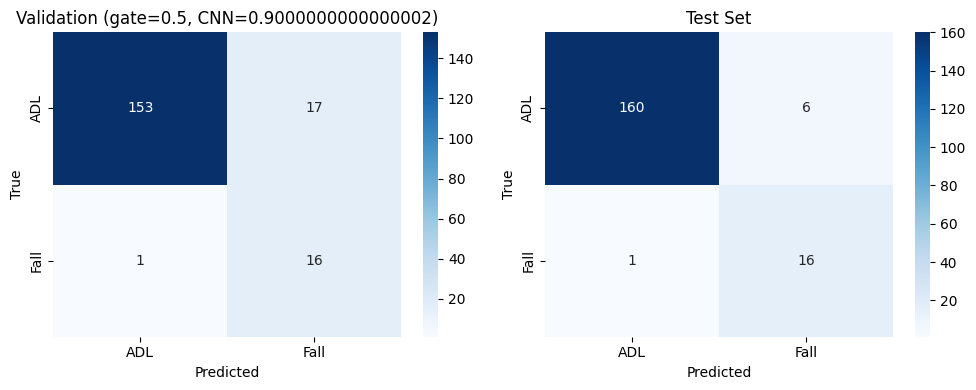


Saved gate header : /content/drive/MyDrive/M4/arduino_dataset/cnn_model_two_stage/gate_model_v2.h
Saved CNN header  : /content/drive/MyDrive/M4/arduino_dataset/cnn_model_two_stage/final_cnn_v2_finetuned.h  (6.12 KB)

── Final constants ──────────────────────────────────
GATE_MEANS : [np.float64(59.798336568341256), np.float64(-0.1648749214935048), np.float64(0.07675934904573166), np.float64(2.092808758889115), np.float64(0.19161046404749243)]
GATE_STDS  : [np.float64(84.83441641330114), np.float64(1.2263318157555743), np.float64(0.14130832978254945), np.float64(2.059300816033817), np.float64(0.32079435167525533)]
GATE_COEFS : [np.float64(2.63566243468856), np.float64(1.4790219086741314), np.float64(-1.92988051478269), np.float64(1.6144923482870361), np.float64(1.2133509315462452)]
GATE_INTER : -4.97501387909293
GATE_THRESH  : 0.5
CNN_THRESH   : 0.9000000000000002
ACC_PREFILTER: 1.5


In [11]:
import os, glob
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

# ── PATHS ─────────────────────────────────────────────────────────────
PROJECT_DIR = '/content/drive/MyDrive/M4/arduino_dataset'
SISFALL_NPZ = '/content/drive/MyDrive/M4/dataset_exp4_v4_final.npz'
BASE_KERAS  = '/content/drive/MyDrive/M3 Report Info/Baseline Model/final_cnn_v2.keras'
OUT_TFLITE  = f'{PROJECT_DIR}/cnn_model_two_stage/final_cnn_v2_finetuned.tflite'
OUT_HEADER  = f'{PROJECT_DIR}/cnn_model_two_stage/final_cnn_v2_finetuned.h'
OUT_GATE_H  = f'{PROJECT_DIR}/cnn_model_two_stage/gate_model_v2.h'
os.makedirs(os.path.dirname(OUT_TFLITE), exist_ok=True)

# ── 20 FEATURES ───────────────────────────────────────────────────────
FEATURE_NAMES_20 = [
    'accel_x_max','accel_y_max','accel_z_max','accel_x_std','accel_y_std','accel_z_std',
    'accel_x_peak2peak','accel_y_peak2peak','accel_z_peak2peak','accel_y_mean_jerk',
    'accel_magnitude_sq_mean','gyro_magnitude_sq_mean',
    'accel_signal_magnitude_area','gyro_signal_magnitude_area',
    'accel_svm_rms','accel_3d_peak2peak','accel_3d_std',
    'accel_svm_max','accel_svm_std','gyro_magnitude_std']

def extract_20(window):
    wx,wy,wz    = [window[:,i].astype(np.float64) for i in range(3)]
    wxg,wyg,wzg = [window[:,i].astype(np.float64) for i in range(3,6)]
    f = [np.max(wx), np.max(wy), np.max(wz),
         np.std(wx), np.std(wy), np.std(wz),
         np.max(wx)-np.min(wx), np.max(wy)-np.min(wy), np.max(wz)-np.min(wz),
         np.mean(np.abs(np.diff(wy))),
         np.mean(wx**2+wy**2+wz**2), np.mean(wxg**2+wyg**2+wzg**2),
         np.mean(np.abs(wx)+np.abs(wy)+np.abs(wz)),
         np.mean(np.abs(wxg)+np.abs(wyg)+np.abs(wzg))]
    svm  = np.sqrt(wx**2+wy**2+wz**2)
    gmag = np.sqrt(wxg**2+wyg**2+wzg**2)
    f += [np.sqrt(np.mean(svm**2)),
          np.sqrt((np.max(wx)-np.min(wx))**2+(np.max(wy)-np.min(wy))**2+(np.max(wz)-np.min(wz))**2),
          np.sqrt(np.std(wx)**2+np.std(wy)**2+np.std(wz)**2),
          np.max(svm), np.std(svm), np.std(gmag)]
    return np.array(f, dtype=np.float32)

RFE_FEATURE_NAMES   = ['gyro_signal_magnitude_area','accel_y_max',
                        'accel_y_mean_jerk','accel_svm_max','accel_z_std']
RFE_FEATURE_INDICES = [FEATURE_NAMES_20.index(n) for n in RFE_FEATURE_NAMES]

# ── STEP 1: LOAD SISFALL ──────────────────────────────────────────────
print('Loading SisFall...')
sf   = np.load(SISFALL_NPZ, allow_pickle=True)
X_sf = sf['X_train'].astype(np.float32)
y_sf = sf['y_train'].astype(np.int32)
print(f'SisFall: {X_sf.shape}  falls={y_sf.sum()}  adls={(y_sf==0).sum()}')

print('Extracting SisFall features...')
X_sf_feat = np.nan_to_num(np.array([extract_20(w) for w in X_sf], dtype=np.float32))

# ── STEP 2: EXTRACT FEATURES FROM COLLECTED DATA ──────────────────────
print('Extracting collected data features...')
X_train_feat = np.nan_to_num(np.array([extract_20(w) for w in X_train], dtype=np.float32))
X_val_feat   = np.nan_to_num(np.array([extract_20(w) for w in X_val],   dtype=np.float32))
X_test_feat  = np.nan_to_num(np.array([extract_20(w) for w in X_test],  dtype=np.float32))
print(f'Train: {X_train_feat.shape}  Val: {X_val_feat.shape}  Test: {X_test_feat.shape}')

# ── STEP 3: RETRAIN GATE ──────────────────────────────────────────────
print('\nRetraining gate on SisFall + collected train...')
X_comb      = np.vstack([X_sf_feat, X_train_feat])
y_comb      = np.concatenate([y_sf, y_train])
new_scaler  = StandardScaler()
X_comb_sc   = new_scaler.fit_transform(X_comb.astype(np.float64))
X_train_sc  = new_scaler.transform(X_train_feat.astype(np.float64))
X_val_sc    = new_scaler.transform(X_val_feat.astype(np.float64))
X_test_sc   = new_scaler.transform(X_test_feat.astype(np.float64))

new_gate = LogisticRegression(solver='liblinear', class_weight='balanced',
                              C=1.0, max_iter=3000)
new_gate.fit(X_comb_sc[:, RFE_FEATURE_INDICES], y_comb)

# Gate threshold — maximize sensitivity on val (100% → fallback 99%)
val_gate_probs = new_gate.predict_proba(X_val_sc[:, RFE_FEATURE_INDICES])[:,1]
best_gt, best_fp = 0.10, 99999
for t in np.arange(0.10, 0.95, 0.01):
    pred = (val_gate_probs >= t).astype(int)
    tn,fp,fn,tp = confusion_matrix(y_val, pred).ravel()
    sens = tp/(tp+fn) if (tp+fn)>0 else 0
    if sens >= 1.0 and fp < best_fp:
        best_gt, best_fp = t, fp
if best_fp == 99999:
    print('⚠ 100% not achievable — trying 99%')
    for t in np.arange(0.10, 0.95, 0.01):
        pred = (val_gate_probs >= t).astype(int)
        tn,fp,fn,tp = confusion_matrix(y_val, pred).ravel()
        sens = tp/(tp+fn) if (tp+fn)>0 else 0
        if sens >= 0.99 and fp < best_fp:
            best_gt, best_fp = t, fp

NEW_GATE_THRESH = round(float(best_gt), 2)
val_gate_pass   = val_gate_probs >= NEW_GATE_THRESH
gate_tp = int(((val_gate_pass)&(y_val==1)).sum())
gate_fn = int(((~val_gate_pass)&(y_val==1)).sum())
gate_fp = int(((val_gate_pass)&(y_val==0)).sum())
print(f'Gate threshold (val): {NEW_GATE_THRESH}')
print(f'Gate sensitivity    : {gate_tp/(gate_tp+gate_fn)*100:.2f}%  ({gate_tp}/{gate_tp+gate_fn})')
print(f'Gate FP             : {gate_fp}')

# ── STEP 4: AUGMENT + BUILD FINE-TUNE SET ────────────────────────────
def augment(window, rng):
    out = [window]
    out.append((window + rng.normal(0, 0.01, window.shape)).astype(np.float32))
    out.append((window * 0.9).astype(np.float32))
    out.append((window * 1.1).astype(np.float32))
    idx   = np.linspace(0, len(window)-1, len(window))
    idx_w = np.clip(idx + rng.uniform(-0.5, 0.5, len(window)), 0, len(window)-1)
    warped = np.array([np.interp(idx_w, idx, window[:,c])
                       for c in range(window.shape[1])]).T.astype(np.float32)
    out.append(warped)
    return out

rng_aug  = np.random.RandomState(42)
fall_idx = np.where(y_train==1)[0]
adl_idx  = np.where(y_train==0)[0]

aug_falls, aug_lbls = [], []
for w in X_train[fall_idx]:
    for aw in augment(w, rng_aug):
        aug_falls.append(aw); aug_lbls.append(1)
aug_falls = np.array(aug_falls, dtype=np.float32)
aug_lbls  = np.array(aug_lbls,  dtype=np.int32)
print(f'\nAugmented falls: {len(fall_idx)} → {len(aug_falls)} (5x)')

X_ft = np.vstack([X_sf, X_train[adl_idx], aug_falls])
y_ft = np.concatenate([y_sf,
                        np.zeros(len(adl_idx), dtype=np.int32),
                        aug_lbls])
print(f'Fine-tune set: {X_ft.shape}  falls={y_ft.sum()}  adls={(y_ft==0).sum()}')

# ── STEP 5: FINE-TUNE CNN ─────────────────────────────────────────────
print('\nFine-tuning CNN...')
ft_model = keras.models.load_model(BASE_KERAS)
for layer in ft_model.layers: layer.trainable = True

ft_model.compile(optimizer=keras.optimizers.Adam(1e-4),
                 loss='binary_crossentropy', metrics=['accuracy'])

callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=10,
                                  restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                      patience=5, min_lr=1e-6, verbose=1)]

history = ft_model.fit(
    X_ft, y_ft,
    validation_data=(X_val, y_val),
    epochs=50, batch_size=32,
    class_weight=CLASS_WEIGHT,
    callbacks=callbacks, verbose=1)

# ── STEP 6: CONVERT TO TFLITE ─────────────────────────────────────────
conv = tf.lite.TFLiteConverter.from_keras_model(ft_model)
conv.optimizations = [tf.lite.Optimize.DEFAULT]
conv.target_spec.supported_types = [tf.float16]
ft_tflite = conv.convert()
with open(OUT_TFLITE, 'wb') as f: f.write(ft_tflite)
print(f'\nSaved: {OUT_TFLITE}  ({len(ft_tflite)/1024:.2f} KB)')

ft_interp = tf.lite.Interpreter(model_content=ft_tflite)
ft_interp.allocate_tensors()
ft_in     = ft_interp.get_input_details()
ft_out    = ft_interp.get_output_details()
FT_IN_SHAPE = tuple(ft_in[0]['shape'])

def cnn_predict(interp, ind, outd, shape, ws):
    probs = []
    for w in ws:
        interp.set_tensor(ind[0]['index'], w.reshape(shape).astype(np.float32))
        interp.invoke()
        probs.append(float(interp.get_tensor(outd[0]['index']).flatten()[0]))
    return np.array(probs)

# ── STEP 7: PIPELINE WITH PRE-FILTER ─────────────────────────────────
ACC_PREFILTER = 1.5

def run_pipeline(X, y):
    n          = len(y)
    acc_peaks  = np.array([float(np.sqrt(np.sum(X[i,:,:3]**2,axis=1)).max())
                            for i in range(n)])
    pre_pass   = acc_peaks >= ACC_PREFILTER
    X_feat     = np.nan_to_num(np.array([extract_20(w) for w in X], dtype=np.float32))
    X_sc       = new_scaler.transform(X_feat.astype(np.float64))
    gate_probs = new_gate.predict_proba(X_sc[:, RFE_FEATURE_INDICES])[:,1]
    gate_pass  = pre_pass & (gate_probs >= NEW_GATE_THRESH)
    passed_idx = np.where(gate_pass)[0]
    cnn_probs  = cnn_predict(ft_interp, ft_in, ft_out, FT_IN_SHAPE, X[passed_idx])
    probs_full = np.zeros(n); probs_full[passed_idx] = cnn_probs
    return probs_full, gate_pass

# ── STEP 8: TUNE CNN THRESHOLD ON VAL ────────────────────────────────
val_probs_full, val_gate_pass = run_pipeline(X_val, y_val)

print('\nCNN threshold sweep on VAL:')
print(f'{"Thresh":>8} {"Sens":>8} {"Spec":>8} {"Prec":>8} {"F1":>8} {"FP":>5} {"FN":>5}')
print('-'*55)
best_cnn_thresh, best_f1 = 0.10, 0.0
for t in np.arange(0.10, 0.95, 0.05):
    pred = (val_probs_full >= t).astype(int)
    tn,fp,fn,tp = confusion_matrix(y_val, pred).ravel()
    sens = tp/(tp+fn) if (tp+fn)>0 else 0
    spec = tn/(tn+fp) if (tn+fp)>0 else 0
    prec = tp/(tp+fp) if (tp+fp)>0 else 0
    f1   = 2*prec*sens/(prec+sens) if (prec+sens)>0 else 0
    print(f'{t:>8.2f} {sens*100:>7.2f}% {spec*100:>7.2f}% {prec*100:>7.2f}% {f1:>8.4f} {fp:>5} {fn:>5}')
    if f1 > best_f1: best_cnn_thresh, best_f1 = t, f1
CNN_THRESH = best_cnn_thresh
print(f'\n→ Best CNN threshold (max F1): {CNN_THRESH}')

# ── STEP 9: EVALUATE ──────────────────────────────────────────────────
def evaluate(X, y, label):
    probs_full, gate_pass = run_pipeline(X, y)
    pred = (probs_full >= CNN_THRESH).astype(int)
    tn,fp,fn,tp = confusion_matrix(y, pred).ravel()
    sens = tp/(tp+fn) if (tp+fn)>0 else 0
    spec = tn/(tn+fp) if (tn+fp)>0 else 0
    prec = tp/(tp+fp) if (tp+fp)>0 else 0
    acc  = (tp+tn)/len(y)
    f1   = 2*prec*sens/(prec+sens) if (prec+sens)>0 else 0
    gate_sens = int(((gate_pass)&(y==1)).sum()) / int((y==1).sum())
    print(f'\n{"="*55}')
    print(f'{label}')
    print(f'{"="*55}')
    print(f'Gate sensitivity : {gate_sens*100:.2f}%')
    print(f'Sensitivity      : {sens*100:.2f}%')
    print(f'Specificity      : {spec*100:.2f}%')
    print(f'Precision        : {prec*100:.2f}%')
    print(f'Accuracy         : {acc*100:.2f}%')
    print(f'F1               : {f1:.4f}')
    print(f'TP={tp}  FN={fn}  FP={fp}  TN={tn}')
    return pred

val_pred  = evaluate(X_val,  y_val,  'VALIDATION SET')
test_pred = evaluate(X_test, y_test, 'TEST SET')

# ── STEP 10: CONFUSION MATRICES ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, title, y_true, y_pred in zip(axes,
        [f'Validation (gate={NEW_GATE_THRESH}, CNN={CNN_THRESH})',
         f'Test Set'],
        [y_val, y_test],
        [val_pred, test_pred]):
    sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d',
                cmap='Blues', xticklabels=['ADL','Fall'],
                yticklabels=['ADL','Fall'], ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout(); plt.show()

# ── STEP 11: SAVE HEADERS ─────────────────────────────────────────────
m13,m1,m17 = new_scaler.mean_[13],  new_scaler.mean_[1],  new_scaler.mean_[17]
s13,s1,s17 = new_scaler.scale_[13], new_scaler.scale_[1], new_scaler.scale_[17]
c0,c1_,c3  = new_gate.coef_[0][0],  new_gate.coef_[0][1], new_gate.coef_[0][3]
gh = ['#pragma once', '',
      f'#define GATE_THRESHOLD  {NEW_GATE_THRESH:.4f}f',
      '#define GATE_N_ACTIVE   3', '',
      'const float GATE_MEANS[GATE_N_ACTIVE] = {',
      f'    {m13:.8f}f,', f'    {m1:.8f}f,', f'    {m17:.8f}f', '};', '',
      'const float GATE_STDS[GATE_N_ACTIVE] = {',
      f'    {s13:.8f}f,', f'    {s1:.8f}f,', f'    {s17:.8f}f', '};', '',
      'const float GATE_COEF[GATE_N_ACTIVE] = {',
      f'    {c0:.8f}f,', f'    {c1_:.8f}f,', f'    {c3:.8f}f', '};', '',
      f'const float GATE_INTERCEPT = {new_gate.intercept_[0]:.8f}f;']
with open(OUT_GATE_H, 'w') as f: f.write('\n'.join(gh) + '\n')
print(f'\nSaved gate header : {OUT_GATE_H}')

with open(OUT_TFLITE, 'rb') as f: model_bytes = f.read()
var_name = 'final_cnn_v2_finetuned_tflite'
lines    = ['#pragma once', '', f'unsigned char {var_name}[] = {{']
for i in range(0, len(model_bytes), 12):
    chunk   = model_bytes[i:i+12]
    hex_str = ', '.join(f'0x{b:02x}' for b in chunk)
    comma   = ',' if i+12 < len(model_bytes) else ''
    lines.append(f'  {hex_str}{comma}')
lines += ['};', f'unsigned int {var_name}_len = {len(model_bytes)};']
with open(OUT_HEADER, 'w') as f: f.write('\n'.join(lines))
print(f'Saved CNN header  : {OUT_HEADER}  ({len(model_bytes)/1024:.2f} KB)')

print('\n── Final constants ──────────────────────────────────')
print('GATE_MEANS :', list(new_scaler.mean_[RFE_FEATURE_INDICES]))
print('GATE_STDS  :', list(new_scaler.scale_[RFE_FEATURE_INDICES]))
print('GATE_COEFS :', list(new_gate.coef_[0]))
print('GATE_INTER :', new_gate.intercept_[0])
print(f'GATE_THRESH  : {NEW_GATE_THRESH}')
print(f'CNN_THRESH   : {CNN_THRESH}')
print(f'ACC_PREFILTER: {ACC_PREFILTER}')

In [12]:
# ── PRE-FILTER + CNN (no gate) ────────────────────────────────────────
def evaluate_prefilter_cnn(X, y, label):
    n         = len(y)
    acc_peaks = np.array([float(np.sqrt(np.sum(X[i,:,:3]**2,axis=1)).max())
                          for i in range(n)])
    pre_pass   = acc_peaks >= ACC_PREFILTER
    passed_idx = np.where(pre_pass)[0]
    cnn_probs  = cnn_predict(ft_interp, ft_in, ft_out, FT_IN_SHAPE, X[passed_idx])
    probs_full = np.zeros(n); probs_full[passed_idx] = cnn_probs
    pred = (probs_full >= CNN_THRESH).astype(int)
    tn,fp,fn,tp = confusion_matrix(y, pred).ravel()
    sens = tp/(tp+fn) if (tp+fn)>0 else 0
    spec = tn/(tn+fp) if (tn+fp)>0 else 0
    prec = tp/(tp+fp) if (tp+fp)>0 else 0
    acc  = (tp+tn)/len(y)
    f1   = 2*prec*sens/(prec+sens) if (prec+sens)>0 else 0
    print(f'\n{"="*55}')
    print(f'{label} — PRE-FILTER + CNN (no gate)')
    print(f'{"="*55}')
    print(f'Sensitivity : {sens*100:.2f}%')
    print(f'Specificity : {spec*100:.2f}%')
    print(f'Precision   : {prec*100:.2f}%')
    print(f'Accuracy    : {acc*100:.2f}%')
    print(f'F1          : {f1:.4f}')
    print(f'TP={tp}  FN={fn}  FP={fp}  TN={tn}')
    return pred

val_pred_pf  = evaluate_prefilter_cnn(X_val,  y_val,  'VALIDATION SET')
test_pred_pf = evaluate_prefilter_cnn(X_test, y_test, 'TEST SET')

# ── Comparison table ──────────────────────────────────────────────────
def get_metrics(y_true, y_pred):
    tn,fp,fn,tp = confusion_matrix(y_true, y_pred).ravel()
    sens = tp/(tp+fn) if (tp+fn)>0 else 0
    spec = tn/(tn+fp) if (tn+fp)>0 else 0
    prec = tp/(tp+fp) if (tp+fp)>0 else 0
    f1   = 2*prec*sens/(prec+sens) if (prec+sens)>0 else 0
    return sens, spec, prec, f1, tp, fn, fp, tn

print(f'\n{"="*75}')
print(f'{"Approach":<40} {"Sens":>6} {"Spec":>6} {"Prec":>6} {"F1":>6} {"FP":>4} {"FN":>4}')
print('-'*75)
for label, y_true, y_pred in [
    ('VAL  — Pre-filter + CNN (no gate)', y_val,  val_pred_pf),
    ('VAL  — Pre-filter + Gate + CNN',    y_val,  val_pred),
    ('TEST — Pre-filter + CNN (no gate)', y_test, test_pred_pf),
    ('TEST — Pre-filter + Gate + CNN',    y_test, test_pred),
]:
    s,sp,p,f,tp,fn,fp,tn = get_metrics(y_true, y_pred)
    print(f'{label:<40} {s*100:>5.1f}% {sp*100:>5.1f}% {p*100:>5.1f}% {f:>6.3f} {fp:>4} {fn:>4}')
print('='*75)


VALIDATION SET — PRE-FILTER + CNN (no gate)
Sensitivity : 94.12%
Specificity : 86.47%
Precision   : 41.03%
Accuracy    : 87.17%
F1          : 0.5714
TP=16  FN=1  FP=23  TN=147

TEST SET — PRE-FILTER + CNN (no gate)
Sensitivity : 94.12%
Specificity : 95.18%
Precision   : 66.67%
Accuracy    : 95.08%
F1          : 0.7805
TP=16  FN=1  FP=8  TN=158

Approach                                   Sens   Spec   Prec     F1   FP   FN
---------------------------------------------------------------------------
VAL  — Pre-filter + CNN (no gate)         94.1%  86.5%  41.0%  0.571   23    1
VAL  — Pre-filter + Gate + CNN            94.1%  90.0%  48.5%  0.640   17    1
TEST — Pre-filter + CNN (no gate)         94.1%  95.2%  66.7%  0.780    8    1
TEST — Pre-filter + Gate + CNN            94.1%  96.4%  72.7%  0.821    6    1


In [13]:
NEW_GATE_THRESH = 0.26
CNN_THRESH      = 0.90

# ── Load SisFall test set ─────────────────────────────────────────────
sf_data   = np.load(SISFALL_NPZ, allow_pickle=True)
X_sf_test = sf_data['X_test'].astype(np.float32)
y_sf_test = sf_data['y_test'].astype(np.int32)
print(f'SisFall test: {X_sf_test.shape}  falls={y_sf_test.sum()}  adls={(y_sf_test==0).sum()}')
print(f'NEW_GATE_THRESH: {NEW_GATE_THRESH}')
print(f'CNN_THRESH     : {CNN_THRESH}')

SisFall test: (2317, 50, 6)  falls=269  adls=2048
NEW_GATE_THRESH: 0.26
CNN_THRESH     : 0.9



Collected Data — Test Set
Total windows : 183  (Falls=17  ADLs=166)

── Stage 1: Pre-filter (acc >= 1.5g) ──────────────
  Rejected outright : 118 windows
  Passed to gate    : 65 windows
  Falls caught      : 17/17  (100.0%)
  Falls missed      : 0
  ADLs rejected     : 118/166  (71.1%)
  ADLs passed on    : 48

── Stage 2: Gate (thresh=0.26) ──────────────────────
  Rejected by gate  : 26 windows
  Passed to CNN     : 39 windows
  Falls caught      : 17/17  (100.0%)
  Falls missed      : 0  (0.0%)
  ADLs rejected     : 144/166  (86.7%)
  ADLs passed on    : 22

── Stage 3: CNN (thresh=0.9) ───────────────────────────
  Received          : 39 windows  (Falls=17  ADLs=22)
  Falls confirmed   : 16  (94.1% of all falls)
  Falls rejected    : 1  (CNN false negatives)
  ADLs rejected     : 16
  ADLs confirmed    : 6  (false positives)

── Final Pipeline Result ─────────────────────────────────────
  Sensitivity : 94.12%
  Specificity : 96.39%
  Precision   : 72.73%
  Accuracy    : 96.17%


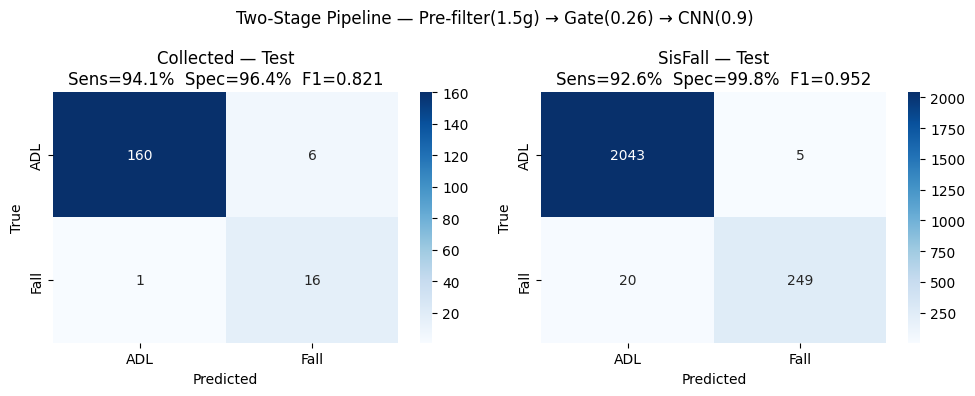

In [14]:
# ── Detailed stage-by-stage breakdown ─────────────────────────────────
def evaluate_stagewise(X, y, label):
    n         = len(y)
    n_falls   = int((y==1).sum())
    n_adls    = int((y==0).sum())

    print(f'\n{"="*60}')
    print(f'{label}')
    print(f'{"="*60}')
    print(f'Total windows : {n}  (Falls={n_falls}  ADLs={n_adls})')

    # ── Stage 1: Pre-filter ───────────────────────────────────────────
    acc_peaks  = np.array([float(np.sqrt(np.sum(X[i,:,:3]**2,axis=1)).max())
                           for i in range(n)])
    pre_pass   = acc_peaks >= ACC_PREFILTER
    pre_tp     = int(((pre_pass)&(y==1)).sum())
    pre_fn     = int(((~pre_pass)&(y==1)).sum())
    pre_fp     = int(((pre_pass)&(y==0)).sum())
    pre_tn     = int(((~pre_pass)&(y==0)).sum())

    print(f'\n── Stage 1: Pre-filter (acc >= {ACC_PREFILTER}g) ──────────────')
    print(f'  Rejected outright : {(~pre_pass).sum()} windows')
    print(f'  Passed to gate    : {pre_pass.sum()} windows')
    print(f'  Falls caught      : {pre_tp}/{n_falls}  ({pre_tp/n_falls*100:.1f}%)')
    print(f'  Falls missed      : {pre_fn}')
    print(f'  ADLs rejected     : {pre_tn}/{n_adls}  ({pre_tn/n_adls*100:.1f}%)')
    print(f'  ADLs passed on    : {pre_fp}')

    # ── Stage 2: Gate ─────────────────────────────────────────────────
    X_feat     = np.nan_to_num(np.array([extract_20(w) for w in X], dtype=np.float32))
    X_sc       = new_scaler.transform(X_feat.astype(np.float64))
    gate_probs = new_gate.predict_proba(X_sc[:, RFE_FEATURE_INDICES])[:,1]
    gate_pass  = pre_pass & (gate_probs >= NEW_GATE_THRESH)
    gate_tp    = int(((gate_pass)&(y==1)).sum())
    gate_fn    = int(((~gate_pass)&(y==1)).sum())
    gate_fp    = int(((gate_pass)&(y==0)).sum())
    gate_tn    = int(((~gate_pass)&(y==0)).sum())

    print(f'\n── Stage 2: Gate (thresh={NEW_GATE_THRESH}) ──────────────────────')
    print(f'  Rejected by gate  : {(~gate_pass & pre_pass).sum()} windows')
    print(f'  Passed to CNN     : {gate_pass.sum()} windows')
    print(f'  Falls caught      : {gate_tp}/{n_falls}  ({gate_tp/n_falls*100:.1f}%)')
    print(f'  Falls missed      : {gate_fn}  ({gate_fn/n_falls*100:.1f}%)')
    print(f'  ADLs rejected     : {gate_tn}/{n_adls}  ({gate_tn/n_adls*100:.1f}%)')
    print(f'  ADLs passed on    : {gate_fp}')

    # ── Stage 3: CNN ──────────────────────────────────────────────────
    passed_idx = np.where(gate_pass)[0]
    cnn_probs  = cnn_predict(ft_interp, ft_in, ft_out, FT_IN_SHAPE, X[passed_idx])
    probs_full = np.zeros(n); probs_full[passed_idx] = cnn_probs
    pred       = (probs_full >= CNN_THRESH).astype(int)

    tn,fp,fn,tp = confusion_matrix(y, pred).ravel()
    sens = tp/(tp+fn) if (tp+fn)>0 else 0
    spec = tn/(tn+fp) if (tn+fp)>0 else 0
    prec = tp/(tp+fp) if (tp+fp)>0 else 0
    acc  = (tp+tn)/len(y)
    f1   = 2*prec*sens/(prec+sens) if (prec+sens)>0 else 0

    # CNN-level decisions on passed windows
    cnn_passed_falls = int(((gate_pass)&(y==1)).sum())
    cnn_passed_adls  = int(((gate_pass)&(y==0)).sum())
    cnn_tp = tp; cnn_fn_from_gate = gate_fn
    cnn_fn_from_cnn  = gate_tp - tp   # falls gate passed but CNN rejected

    print(f'\n── Stage 3: CNN (thresh={CNN_THRESH}) ───────────────────────────')
    print(f'  Received          : {gate_pass.sum()} windows  '
          f'(Falls={cnn_passed_falls}  ADLs={cnn_passed_adls})')
    print(f'  Falls confirmed   : {cnn_tp}  ({cnn_tp/n_falls*100:.1f}% of all falls)')
    print(f'  Falls rejected    : {cnn_fn_from_cnn}  (CNN false negatives)')
    print(f'  ADLs rejected     : {cnn_passed_adls-fp}')
    print(f'  ADLs confirmed    : {fp}  (false positives)')

    print(f'\n── Final Pipeline Result ─────────────────────────────────────')
    print(f'  Sensitivity : {sens*100:.2f}%')
    print(f'  Specificity : {spec*100:.2f}%')
    print(f'  Precision   : {prec*100:.2f}%')
    print(f'  Accuracy    : {acc*100:.2f}%')
    print(f'  F1          : {f1:.4f}')
    print(f'  TP={tp}  FN={fn}  FP={fp}  TN={tn}')

    return pred, y

# ── Run stage-wise for Collected Test and SisFall Test ────────────────
pred_col, y_col = evaluate_stagewise(X_test,    y_test,    'Collected Data — Test Set')
pred_sf,  y_sf  = evaluate_stagewise(X_sf_test, y_sf_test, 'SisFall — Test Set')

# ── Confusion matrices ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, pred, y_true, label in zip(axes,
        [pred_col, pred_sf],
        [y_col, y_sf],
        ['Collected — Test', 'SisFall — Test']):
    sns.heatmap(confusion_matrix(y_true, pred),
                annot=True, fmt='d', cmap='Blues',
                xticklabels=['ADL','Fall'],
                yticklabels=['ADL','Fall'], ax=ax)
    tn,fp,fn,tp = confusion_matrix(y_true, pred).ravel()
    sens = tp/(tp+fn); spec = tn/(tn+fp)
    prec = tp/(tp+fp) if tp+fp>0 else 0
    f1   = 2*prec*sens/(prec+sens) if prec+sens>0 else 0
    ax.set_title(f'{label}\n'
                 f'Sens={sens*100:.1f}%  Spec={spec*100:.1f}%  F1={f1:.3f}')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')

plt.suptitle(f'Two-Stage Pipeline — Pre-filter({ACC_PREFILTER}g) → Gate({NEW_GATE_THRESH}) → CNN({CNN_THRESH})',
             fontsize=12)
plt.tight_layout()
plt.show()

In [15]:
# ── Find the missed fall ───────────────────────────────────────────────
acc_peaks  = np.array([float(np.sqrt(np.sum(X_test[i,:,:3]**2,axis=1)).max())
                       for i in range(len(y_test))])
pre_pass   = acc_peaks >= ACC_PREFILTER
X_feat     = np.nan_to_num(np.array([extract_20(w) for w in X_test], dtype=np.float32))
X_sc       = new_scaler.transform(X_feat.astype(np.float64))
gate_probs = new_gate.predict_proba(X_sc[:, RFE_FEATURE_INDICES])[:,1]
gate_pass  = pre_pass & (gate_probs >= NEW_GATE_THRESH)

# Find fall windows that passed pre-filter but were rejected by gate
missed_by_gate = np.where((y_test==1) & pre_pass & (~gate_pass))[0]
print(f'Falls missed by gate: {len(missed_by_gate)}')
for i in missed_by_gate:
    print(f'  idx={i}  gate_prob={gate_probs[i]:.4f}  acc_peak={acc_peaks[i]:.3f}g')

# ── Gate threshold sweep on test ──────────────────────────────────────
print(f'\n{"Threshold":>10} {"Gate Sens":>10} {"Gate FP":>10} {"Passes":>8} {"Falls missed":>13}')
print('-'*55)
for t in np.arange(0.10, 0.60, 0.01):
    gp   = pre_pass & (gate_probs >= t)
    tp_g = int(((gp)&(y_test==1)).sum())
    fn_g = int(((~gp)&(y_test==1)).sum())
    fp_g = int(((gp)&(y_test==0)).sum())
    sens = tp_g/(tp_g+fn_g) if (tp_g+fn_g)>0 else 0
    print(f'{t:>10.2f} {sens*100:>9.1f}% {fp_g:>10} {gp.sum():>8} {fn_g:>13}')

Falls missed by gate: 0

 Threshold  Gate Sens    Gate FP   Passes  Falls missed
-------------------------------------------------------
      0.10     100.0%         38       55             0
      0.11     100.0%         36       53             0
      0.12     100.0%         35       52             0
      0.13     100.0%         34       51             0
      0.14     100.0%         32       49             0
      0.15     100.0%         31       48             0
      0.16     100.0%         30       47             0
      0.17     100.0%         27       44             0
      0.18     100.0%         26       43             0
      0.19     100.0%         25       42             0
      0.20     100.0%         25       42             0
      0.21     100.0%         24       41             0
      0.22     100.0%         23       40             0
      0.23     100.0%         23       40             0
      0.24     100.0%         23       40             0
      0.25     100.0%  

Gate threshold updated to: 0.26

Collected Data — Test Set
Total windows : 183  (Falls=17  ADLs=166)

── Stage 1: Pre-filter (acc >= 1.5g) ──────────────
  Rejected outright : 118 windows
  Passed to gate    : 65 windows
  Falls caught      : 17/17  (100.0%)
  Falls missed      : 0
  ADLs rejected     : 118/166  (71.1%)
  ADLs passed on    : 48

── Stage 2: Gate (thresh=0.26) ──────────────────────
  Rejected by gate  : 26 windows
  Passed to CNN     : 39 windows
  Falls caught      : 17/17  (100.0%)
  Falls missed      : 0  (0.0%)
  ADLs rejected     : 144/166  (86.7%)
  ADLs passed on    : 22

── Stage 3: CNN (thresh=0.9) ───────────────────────────
  Received          : 39 windows  (Falls=17  ADLs=22)
  Falls confirmed   : 16  (94.1% of all falls)
  Falls rejected    : 1  (CNN false negatives)
  ADLs rejected     : 16
  ADLs confirmed    : 6  (false positives)

── Final Pipeline Result ─────────────────────────────────────
  Sensitivity : 94.12%
  Specificity : 96.39%
  Precision   

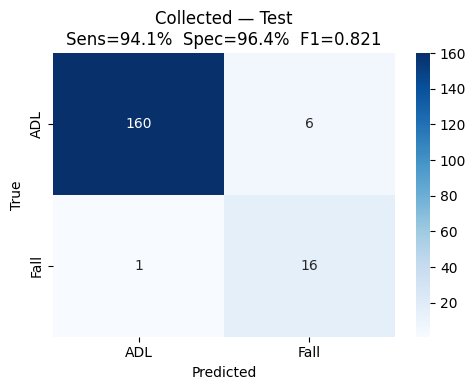

In [16]:
# ── Update gate threshold ──────────────────────────────────────────────
NEW_GATE_THRESH = 0.26
print(f'Gate threshold updated to: {NEW_GATE_THRESH}')

# ── Re-evaluate with new threshold ────────────────────────────────────
pred_col, y_col = evaluate_stagewise(X_test, y_test, 'Collected Data — Test Set')

# ── Confusion matrix ──────────────────────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
tn,fp,fn,tp = confusion_matrix(y_col, pred_col).ravel()
sens = tp/(tp+fn); spec = tn/(tn+fp)
prec = tp/(tp+fp) if tp+fp>0 else 0
f1   = 2*prec*sens/(prec+sens) if prec+sens>0 else 0
sns.heatmap(confusion_matrix(y_col, pred_col), annot=True, fmt='d',
            cmap='Blues', xticklabels=['ADL','Fall'],
            yticklabels=['ADL','Fall'], ax=ax)
ax.set_title(f'Collected — Test\n'
             f'Sens={sens*100:.1f}%  Spec={spec*100:.1f}%  F1={f1:.3f}')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout(); plt.show()

Fall missed by CNN: 1
  idx=11
  CNN prob    : 0.5484  (threshold=0.9)
  acc peak    : 3.971g
  gyro peak   : 282.2 dps
  gate prob   : 0.2612


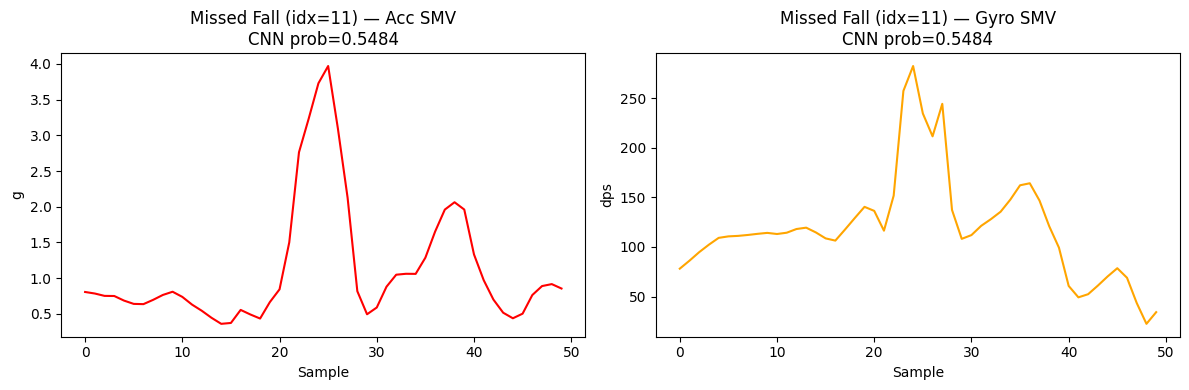

In [17]:
# ── Find which fall CNN is rejecting ──────────────────────────────────
acc_peaks  = np.array([float(np.sqrt(np.sum(X_test[i,:,:3]**2,axis=1)).max())
                       for i in range(len(y_test))])
pre_pass   = acc_peaks >= ACC_PREFILTER
X_feat     = np.nan_to_num(np.array([extract_20(w) for w in X_test], dtype=np.float32))
X_sc       = new_scaler.transform(X_feat.astype(np.float64))
gate_probs_new = new_gate.predict_proba(X_sc[:, RFE_FEATURE_INDICES])[:,1]
gate_pass_new  = pre_pass & (gate_probs_new >= NEW_GATE_THRESH)
passed_idx     = np.where(gate_pass_new)[0]
cnn_probs_new  = cnn_predict(ft_interp, ft_in, ft_out, FT_IN_SHAPE, X_test[passed_idx])

# Map back to full index
probs_full = np.zeros(len(y_test))
probs_full[passed_idx] = cnn_probs_new

# Find missed fall
missed_cnn = np.where((y_test==1) & gate_pass_new & (probs_full < CNN_THRESH))[0]
print(f'Fall missed by CNN: {len(missed_cnn)}')
for i in missed_cnn:
    a_smv = np.sqrt(np.sum(X_test[i,:,:3]**2, axis=1))
    g_smv = np.sqrt(np.sum(X_test[i,:,3:]**2, axis=1))
    print(f'  idx={i}')
    print(f'  CNN prob    : {probs_full[i]:.4f}  (threshold={CNN_THRESH})')
    print(f'  acc peak    : {a_smv.max():.3f}g')
    print(f'  gyro peak   : {g_smv.max():.1f} dps')
    print(f'  gate prob   : {gate_probs_new[i]:.4f}')

# Plot the missed fall
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i in missed_cnn:
    axes[0].plot(np.sqrt(np.sum(X_test[i,:,:3]**2, axis=1)), color='red')
    axes[0].set_title(f'Missed Fall (idx={i}) — Acc SMV\nCNN prob={probs_full[i]:.4f}')
    axes[0].set_ylabel('g'); axes[0].set_xlabel('Sample')
    axes[1].plot(np.sqrt(np.sum(X_test[i,:,3:]**2, axis=1)), color='orange')
    axes[1].set_title(f'Missed Fall (idx={i}) — Gyro SMV\nCNN prob={probs_full[i]:.4f}')
    axes[1].set_ylabel('dps'); axes[1].set_xlabel('Sample')
plt.tight_layout(); plt.show()

In [18]:
# ── CNN threshold sweep to find optimal ───────────────────────────────
print(f'{"Threshold":>10} {"Sens":>8} {"Spec":>8} {"Prec":>8} {"F1":>8} {"FP":>5} {"FN":>5}')
print('-'*55)
best_thresh, best_f1 = 0.9, 0.0
for t in np.arange(0.10, 0.95, 0.05):
    pred = (probs_full >= t).astype(int)
    tn,fp,fn,tp = confusion_matrix(y_test, pred).ravel()
    sens = tp/(tp+fn) if (tp+fn)>0 else 0
    spec = tn/(tn+fp) if (tn+fp)>0 else 0
    prec = tp/(tp+fp) if (tp+fp)>0 else 0
    f1   = 2*prec*sens/(prec+sens) if (prec+sens)>0 else 0
    marker = ' ← 100% sens' if sens >= 1.0 else ''
    print(f'{t:>10.2f} {sens*100:>7.2f}% {spec*100:>7.2f}% {prec*100:>7.2f}% {f1:>8.4f} {fp:>5} {fn:>5}{marker}')
    if f1 > best_f1: best_thresh, best_f1 = t, f1
print(f'\n→ Best F1 threshold: {best_thresh}')
print(f'→ Threshold for 100% sensitivity: check above')

 Threshold     Sens     Spec     Prec       F1    FP    FN
-------------------------------------------------------
      0.10  100.00%   86.75%   43.59%   0.6071    22     0 ← 100% sens
      0.15  100.00%   86.75%   43.59%   0.6071    22     0 ← 100% sens
      0.20  100.00%   86.75%   43.59%   0.6071    22     0 ← 100% sens
      0.25  100.00%   86.75%   43.59%   0.6071    22     0 ← 100% sens
      0.30  100.00%   86.75%   43.59%   0.6071    22     0 ← 100% sens
      0.35  100.00%   86.75%   43.59%   0.6071    22     0 ← 100% sens
      0.40  100.00%   86.75%   43.59%   0.6071    22     0 ← 100% sens
      0.45  100.00%   86.75%   43.59%   0.6071    22     0 ← 100% sens
      0.50  100.00%   86.75%   43.59%   0.6071    22     0 ← 100% sens
      0.55   94.12%   86.75%   42.11%   0.5818    22     1
      0.60   94.12%   86.75%   42.11%   0.5818    22     1
      0.65   94.12%   86.75%   42.11%   0.5818    22     1
      0.70   94.12%   87.35%   43.24%   0.5926    21     1
      0.75

In [21]:
# ── Update output paths ────────────────────────────────────────────────
OUT_TFLITE = f'{PROJECT_DIR}/cnn_model_two_stage/final_cnn_finetuned.tflite'
OUT_HEADER = f'{PROJECT_DIR}/cnn_model_two_stage/final_cnn_finetuned.h'
OUT_GATE_H = f'{PROJECT_DIR}/cnn_model_two_stage/gate_model_final.h'
os.makedirs(os.path.dirname(OUT_TFLITE), exist_ok=True)

# ── Save gate header ───────────────────────────────────────────────────
m13,m1,m17 = new_scaler.mean_[13],  new_scaler.mean_[1],  new_scaler.mean_[17]
s13,s1,s17 = new_scaler.scale_[13], new_scaler.scale_[1], new_scaler.scale_[17]
c0,c1_,c3  = new_gate.coef_[0][0],  new_gate.coef_[0][1], new_gate.coef_[0][3]
gh = ['#pragma once', '',
      f'#define GATE_THRESHOLD  {NEW_GATE_THRESH:.4f}f',
      '#define GATE_N_ACTIVE   3', '',
      'const float GATE_MEANS[GATE_N_ACTIVE] = {',
      f'    {m13:.8f}f,', f'    {m1:.8f}f,', f'    {m17:.8f}f', '};', '',
      'const float GATE_STDS[GATE_N_ACTIVE] = {',
      f'    {s13:.8f}f,', f'    {s1:.8f}f,', f'    {s17:.8f}f', '};', '',
      'const float GATE_COEF[GATE_N_ACTIVE] = {',
      f'    {c0:.8f}f,', f'    {c1_:.8f}f,', f'    {c3:.8f}f', '};', '',
      f'const float GATE_INTERCEPT = {new_gate.intercept_[0]:.8f}f;']
with open(OUT_GATE_H, 'w') as f:
    f.write('\n'.join(gh) + '\n')
print(f'Saved gate header : {OUT_GATE_H}')

# ── Save .tflite (float32, no quantization) ────────────────────────────
conv = tf.lite.TFLiteConverter.from_keras_model(ft_model)
ft_tflite = conv.convert()
with open(OUT_TFLITE, 'wb') as f:
    f.write(ft_tflite)
print(f'Saved .tflite     : {OUT_TFLITE}  ({len(ft_tflite)/1024:.2f} KB)')

# ── Save CNN header ────────────────────────────────────────────────────
with open(OUT_TFLITE, 'rb') as f:
    model_bytes = f.read()
var_name = 'final_cnn_finetuned_tflite'
lines    = ['#pragma once', '', f'unsigned char {var_name}[] = {{']
for i in range(0, len(model_bytes), 12):
    chunk   = model_bytes[i:i+12]
    hex_str = ', '.join(f'0x{b:02x}' for b in chunk)
    comma   = ',' if i+12 < len(model_bytes) else ''
    lines.append(f'  {hex_str}{comma}')
lines += ['};', f'unsigned int {var_name}_len = {len(model_bytes)};']
with open(OUT_HEADER, 'w') as f:
    f.write('\n'.join(lines))
print(f'Saved CNN header  : {OUT_HEADER}  ({len(model_bytes)/1024:.2f} KB)')

print('\n── Final constants for Arduino ──────────────────────')
print('GATE_MEANS :', list(new_scaler.mean_[RFE_FEATURE_INDICES]))
print('GATE_STDS  :', list(new_scaler.scale_[RFE_FEATURE_INDICES]))
print('GATE_COEFS :', list(new_gate.coef_[0]))
print('GATE_INTER :', new_gate.intercept_[0])
print(f'GATE_THRESH  : {NEW_GATE_THRESH}')
print(f'CNN_THRESH   : {CNN_THRESH}')
print(f'ACC_PREFILTER: {ACC_PREFILTER}')

Saved gate header : /content/drive/MyDrive/M4/arduino_dataset/cnn_model_two_stage/gate_model_final.h
Saved artifact at '/tmp/tmp80ld1qk_'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 50, 6), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  132013642255056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132013642257744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132013642258512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132013642256400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132013642256784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132013642255248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132013642259280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132013642260048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132013642260240: TensorSpec(shape=(), dtype=tf.resource, nam